<a href="https://colab.research.google.com/github/manasa7695-dotcom/ML-projects/blob/main/CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install tensorflow
import tensorflow as tf
from tensorflow import keras
from keras.models import Sequential
from keras.layers import Dense, Flatten, Conv2D, MaxPooling2D, Dropout

In [ ]:
from tensorflow.keras import layers

In [ ]:
from keras.utils import to_categorical
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
plt.style.use('fivethirtyeight')

In [ ]:
from keras.datasets import cifar10

In [ ]:
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

In [ ]:
type(x_train)

numpy.ndarray

In [ ]:
x_train.shape

(50000, 32, 32, 3)

array([[[53, 65, 53],
        [54, 63, 52],
        [56, 60, 50],
        ...,
        [47, 51, 50],
        [41, 45, 44],
        [24, 28, 27]],

       [[46, 59, 41],
        [53, 62, 45],
        [54, 59, 44],
        ...,
        [42, 46, 45],
        [39, 43, 42],
        [28, 32, 31]],

       [[45, 59, 38],
        [50, 60, 41],
        [46, 52, 34],
        ...,
        [38, 42, 41],
        [36, 40, 39],
        [29, 33, 32]],

       ...,

       [[71, 83, 66],
        [74, 83, 66],
        [80, 85, 67],
        ...,
        [51, 54, 33],
        [46, 49, 34],
        [49, 50, 41]],

       [[75, 82, 67],
        [79, 85, 69],
        [81, 85, 67],
        ...,
        [61, 65, 41],
        [64, 67, 48],
        [48, 50, 41]],

       [[85, 83, 71],
        [85, 84, 71],
        [86, 86, 70],
        ...,
        [61, 65, 39],
        [64, 67, 46],
        [49, 50, 41]]], dtype=uint8)
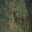

In [ ]:
x_train[10]

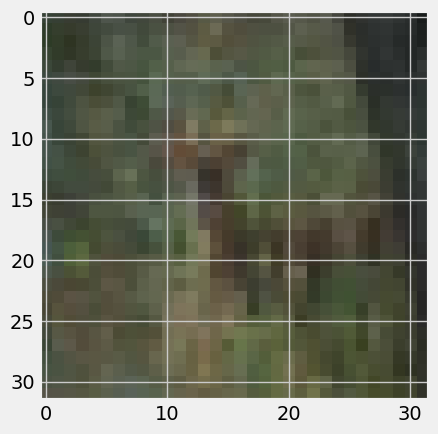

In [ ]:
img0=plt.imshow(x_train[10])

In [ ]:
lab1=y_train[10]
print(lab1)

[4]


In [ ]:
classification=['airplane','automobile','bird','cat','deer','dog','frog','horse','ship','truck']

In [ ]:
print('image class is',classification[y_train[10][0]])

image class is deer


In [ ]:
y_train_cat=to_categorical(y_train)
y_test_cat=to_categorical(y_test)

In [ ]:
y_train_cat[10]

array([0., 0., 0., 0., 1., 0., 0., 0., 0., 0.])

In [ ]:
x_train=x_train/255
x_test=x_test/255

In [ ]:
model=Sequential()
model.add(Conv2D(32,(3,3),activation='relu',input_shape=(32,32,3)))
model.add(MaxPooling2D((2,2)))
model.add(Conv2D(64,(3,3),activation='relu'))
model.add(MaxPooling2D((2,2)))
model.add(Conv2D(64,(3,3),activation='relu'))
model.add(Flatten())
model.add(Dense(1000,activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(500,activation='softmax'))
model.add(Dropout(0.5))
model.add(Dense(250,activation='relu'))
model.add(Dense(10,activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 4, 4, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1000)           │     1,025,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1000)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 500)            │       500,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 500)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 250)            │       125,250 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         2,510 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,709,580 (6.52 MB)

 Trainable params: 1,709,580 (6.52 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(loss='categorical_crossentropy',optimizer='adam',metrics=['accuracy'])

In [ ]:
tr=model.fit(x_train,y_train_cat,epochs=20,batch_size=250,validation_split=0.2)
model.evaluate(x_test,y_test_cat)

Epoch 1/20
160/160 ━━━━━━━━━━━━━━━━━━━━ 74s 425ms/step - accuracy: 0.1670 - loss: 2.1449 - val_accuracy: 0.2209 - val_loss: 1.9261
Epoch 2/20
160/160 ━━━━━━━━━━━━━━━━━━━━ 61s 382ms/step - accuracy: 0.2840 - loss: 1.8284 - val_accuracy: 0.3799 - val_loss: 1.6305
Epoch 3/20
160/160 ━━━━━━━━━━━━━━━━━━━━ 81s 378ms/step - accuracy: 0.3990 - loss: 1.5883 - val_accuracy: 0.4574 - val_loss: 1.4931
Epoch 4/20
160/160 ━━━━━━━━━━━━━━━━━━━━ 62s 389ms/step - accuracy: 0.4815 - loss: 1.4177 - val_accuracy: 0.5116 - val_loss: 1.3319
Epoch 5/20
160/160 ━━━━━━━━━━━━━━━━━━━━ 79s 367ms/step - accuracy: 0.5479 - loss: 1.2673 - val_accuracy: 0.5589 - val_loss: 1.2361
Epoch 6/20
160/160 ━━━━━━━━━━━━━━━━━━━━ 59s 370ms/step - accuracy: 0.5871 - loss: 1.1610 - val_accuracy: 0.6052 - val_loss: 1.1148
Epoch 7/20
160/160 ━━━━━━━━━━━━━━━━━━━━ 83s 377ms/step - accuracy: 0.6180 - loss: 1.0803 - val_accuracy: 0.6332 - val_loss: 1.0471
Epoch 8/20
160/160 ━━━━━━━━━━━━━━━━━━━━ 82s 376ms/step - accuracy: 0.6465 - loss: 1

[0.9369648694992065, 0.7041000127792358]

In [ ]:
Dog=plt.imread('/content/dog.jpeg')

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


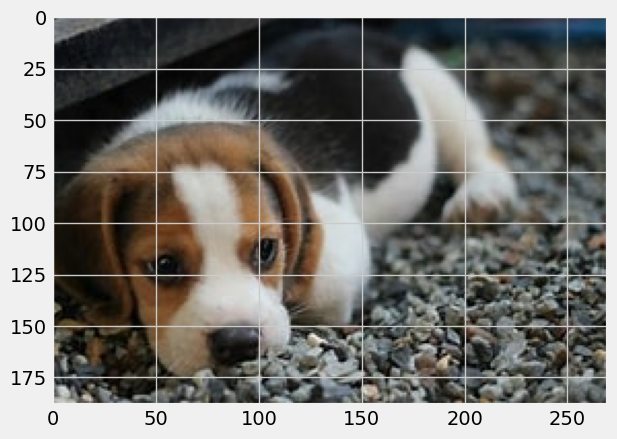

In [ ]:
img=plt.imshow(Dog)

In [ ]:
from skimage import transform
resize=transform.resize(Dog,(32,32,3))

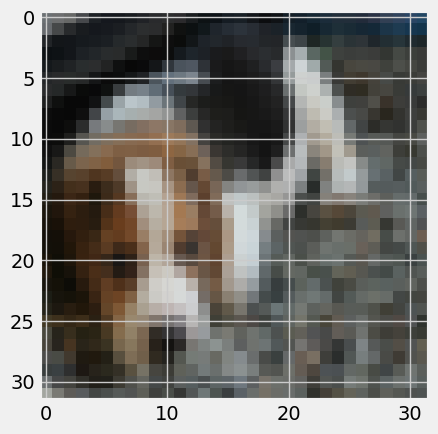

In [ ]:
img=plt.imshow(resize)

In [ ]:
pred=model.predict(np.array([resize]))
print(pred)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 140ms/step
[[5.5173186e-06 1.1666554e-06 2.3929998e-03 8.1614070e-02 1.4846412e-03
  9.0949816e-01 2.1075233e-04 4.7900178e-03 5.2304188e-07 2.0322027e-06]]


In [ ]:
list=[0,1,2,3,4,5,6,7,8,9]
x=pred
for i  in range(10):
  for j in range(10):
    if x[0][list[i]]> x[0][list[j]]:
     temp=list[i]
     list[i]=list[j]
     list[j]=temp
print(list)

[5, 3, 7, 2, 4, 6, 0, 9, 1, 8]


In [ ]:
for i in range(5):
  print(classification[list[i]])

dog
cat
horse
bird
deer
